In [71]:
from cnmodel import populations
from scipy.stats import norm
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import itertools

## Functions

In [2]:
def get_response_map(levels, freqs, results, baseline, response, cell_type, cell_id):
    
    spont_spikes = 0
    spont_time = 0

    # calculate spontaneous firing rate
    for stim, iterations in list(results.values()):
        
        for vec in list(iterations.values()):
            
            spikes = vec[(cell_type, cell_id)][1]
            spont_spikes += ((spikes >= baseline[0]) * (spikes < baseline[1])).sum()
            spont_time += baseline[1] - baseline[0]

    spont_rate = spont_spikes / spont_time

    nreps = 1

    # calculate response firing rate
    matrix = np.zeros((len(levels), len(freqs)))

    for stim, iteration in list(results.values()):

        for i in range(nreps):

            vec = iteration[i]
            spikes = vec[(cell_type, cell_id)][1]
            n_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()

            freq = stim.key()['f0']
            level = stim.key()['dbspl']

            j = freqs.index(freq)
            i = levels.index(level)

            matrix[i,j] += n_spikes - spont_rate * (response[1] - response[0])
    
    return matrix

In [3]:
def get_cell_nspikes(cell_type, results, response, pyr_ids=None):
    n_spikes = []
    cell_ids = []

    for stim, iterations in results.values():
        rep_n_spikes = []
        rep_cell_ids = []
        for cell, vec in iterations.items():
            if isinstance(cell, str):
                continue
            save_rate = True if ('sgc' in cell_type) or (('pyr' in cell_type) and (cell[1] in pyr_ids)) else False
            if (cell_type in cell[0]) and save_rate:
                spikes = np.array(vec[1])
                num_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()
                rep_n_spikes.append(num_spikes)
                rep_cell_ids.append(cell[1])

        n_spikes.append(rep_n_spikes)
        cell_ids.append(rep_cell_ids)

    n_spikes = np.mean(n_spikes, axis=0)

    return cell_ids[0], np.array(n_spikes)

In [ ]:
def get_spontaneous_firing_rate(cell_type, results, baseline, pyr_ids_per_band=None):

    avg_spont_rate = 0

    for stim, iterations in list(results.values()):

        stim_avg_rate  = 0

        n_reps = len(iterations)

        for i in range(n_reps):

            for cell, vec in iterations[i].items():
            # rep_avg_msfs = []

                if isinstance(cell, str):
                    continue

                if cell_type in cell[0]:

                    cell_id = cell[1]

                    spikes = vec[1]
                    n_spikes = ((spikes >= baseline[0]) & (spikes <= baseline[1])).sum()
                    spike_rate = (n_spikes / (baseline[1] - baseline[0])) * 1000  # ms to s

                    stim_avg_rate += spike_rate

        stim_avg_rate /= n_reps
        avg_spont_rate += stim_avg_rate

    avg_spont_rate /= len(results)

    return avg_spont_rate

In [64]:
def get_spontaneous_firing_rates(cell_type, results, baseline, pyr_ids_per_band=None):

    avg_rates = {}
    cell_ids = {}

    for stim, iterations in list(results.values()):

        stim_avg_rates  = []
        stim_cell_ids = []

        n_reps = len(iterations)

        for i in range(n_reps):

            rep_rates = []
            rep_cell_ids = []

            for cell, vec in iterations[i].items():
            # rep_avg_msfs = []

                if isinstance(cell, str):
                    continue

                if cell_type in cell[0]:

                    cell_id = cell[1]

                    spikes = vec[1]
                    n_spikes = ((spikes >= baseline[0]) & (spikes <= baseline[1])).sum()
                    spike_rate = (n_spikes / (baseline[1] - baseline[0])) * 1000  # ms to s

                    rep_rates.append(spike_rate)
                    rep_cell_ids.append(cell_id)
        
            stim_avg_rates.append(rep_rates)
            stim_cell_ids.append(rep_cell_ids)

        stim_avg_rates = np.average(stim_avg_rates, axis=0)
        
        avg_rates[(stim.opts['f0'], stim.opts['dbspl'])] = stim_avg_rates
        cell_ids[(stim.opts['f0'], stim.opts['dbspl'])] = stim_cell_ids[0]

    return cell_ids, avg_rates

In [ ]:
def get_evoked_firing_rate(cell_type, results, response, pyr_ids_per_band=None):

    avg_rates = {}
    cell_ids = {}

    for stim, iterations in list(results.values()):

        stim_avg_rate  = 0
        stim_cell_ids = []

        n_reps = len(iterations)

        for i in range(n_reps):

            for cell, vec in iterations[i].items():
            # rep_avg_msfs = []

                if isinstance(cell, str):
                    continue

                if cell_type in cell[0]:

                    cell_id = cell[1]

                    spikes = vec[1]
                    n_spikes = ((spikes >= response[0]) & (spikes <= response[1])).sum()
                    spike_rate = (n_spikes / (response[1] - response[0])) * 1000  # ms to s

                    stim_cell_ids.append(cell_id)

                    stim_avg_rate += spike_rate

        stim_avg_rate /= n_reps
        
        avg_rates[(stim.opts['f0'], stim.opts['dbspl'])] = stim_avg_rate
        cell_ids[(stim.opts['f0'], stim.opts['dbspl'])] = stim_cell_ids

    return cell_ids, avg_rate

In [55]:
def get_evoked_firing_rates(cell_type, results, response, pyr_ids_per_band=None):

    avg_rates = {}
    cell_ids = {}

    for stim, iterations in list(results.values()):

        stim_avg_rates  = []
        stim_cell_ids = []

        n_reps = len(iterations)

        for i in range(n_reps):

            rep_rates = []
            rep_cell_ids = []

            for cell, vec in iterations[i].items():
            # rep_avg_msfs = []

                if isinstance(cell, str):
                    continue

                if cell_type in cell[0]:

                    cell_id = cell[1]

                    spikes = vec[1]
                    n_spikes = ((spikes >= response[0]) & (spikes <= response[1])).sum()
                    spike_rate = (n_spikes / (response[1] - response[0])) * 1000  # ms to s

                    rep_rates.append(spike_rate)
                    rep_cell_ids.append(cell_id)
        
            stim_avg_rates.append(rep_rates)
            stim_cell_ids.append(rep_cell_ids)

        stim_avg_rates = np.average(stim_avg_rates, axis=0)
        
        avg_rates[(stim.opts['f0'], stim.opts['dbspl'])] = stim_avg_rates
        cell_ids[(stim.opts['f0'], stim.opts['dbspl'])] = stim_cell_ids[0]

    return cell_ids, avg_rates

## Type III - 22 kHZ Characteristic Frequency

In [6]:
t3_syn_weights = {'sp': 0.00044,
                  'vp': 0.0006,
                  'dp': 0.002228}

stimpar = {
    "dur": 0.3,
    "pip": 0.1,
    "start": [0.125],       # equals response start in seconds
    "baseline": [25, 125],  # baseline duration has to equal response duration
    "response": [125, 225],
}

In [7]:
### Response Map

In [4]:
results_od = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-single_cell-simple_syns-25fs_11ls-3nreps-III/SPx0.00044_VPx0.0006/25fs_11dbs_22000cf-results_od.pkl', 'rb'))
data_norm = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-single_cell-simple_syns-25fs_11ls-3nreps-III/SPx0.00044_VPx0.0006/DATA-25fs_11dbs_22000cf-response_map-norm.pkl', 'rb'))

In [5]:
freqs = data_norm['freqs']
freqs_log = data_norm['freqs_log']
levels = data_norm['levels']

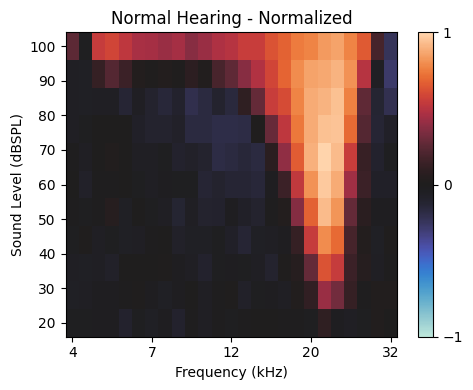

In [19]:
cmap = sns.color_palette("icefire", as_cmap=True)
# cmap = cm.twilight

fig, axs = plt.subplots(1,1,figsize=(5,4))  #, layout='constrained')

matrix = data_norm['matrix']
# matrix_norm = 2*((matrix - np.min(matrix))/(np.max(matrix) - np.min(matrix))) - 1
matrix_norm = matrix / np.max(np.abs(matrix))
im = axs.pcolormesh(freqs_log, levels, matrix_norm, cmap=cmap, vmin=-1, vmax=1) 
axs.set_title('Normal')
axs.set_ylabel('Sound Level (dBSPL)')
axs.set_xticks([freqs_log[i] for i in [0, 6, 12, 18, 24]])
axs.set_xticklabels([4, 7, 12, 20, 32])

# title = 'Hearing Loss' if 'loss' in self.hearing else 'Normal Hearing'
axs.set_title('Normal Hearing - Normalized')
axs.set_xlabel('Frequency (kHz)')

fig.colorbar(im, ticks=[-1,0,1])
# fig.set_dpi(200)
fig.tight_layout()

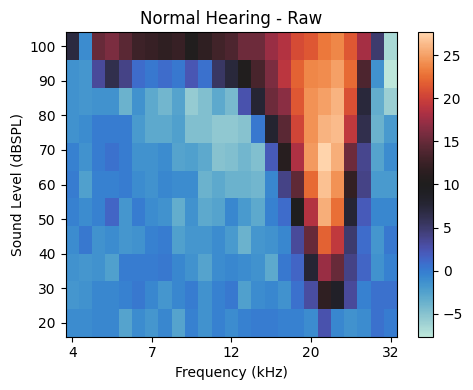

In [18]:
cmap = sns.color_palette("icefire", as_cmap=True)
# cmap = cm.twilight

fig, axs = plt.subplots(1,1,figsize=(5,4))  #, layout='constrained')

matrix = data_norm['matrix']
# matrix_norm = 2*((matrix - np.min(matrix))/(np.max(matrix) - np.min(matrix))) - 1
matrix_norm = matrix / np.max(np.abs(matrix))
im = axs.pcolormesh(freqs_log, levels, matrix, cmap=cmap)  #, vmin=-1, vmax=1) 
axs.set_title('Normal')
axs.set_ylabel('Sound Level (dBSPL)')
axs.set_xticks([freqs_log[i] for i in [0, 6, 12, 18, 24]])
axs.set_xticklabels([4, 7, 12, 20, 32])

# title = 'Hearing Loss' if 'loss' in self.hearing else 'Normal Hearing'
axs.set_title('Normal Hearing - Raw')
axs.set_xlabel('Frequency (kHz)')

fig.colorbar(im)  #, ticks=[-1,0,1])
# fig.set_dpi(200)
fig.tight_layout()

### Rate Level Curves

In [17]:
stimpar = {
    "dur": 0.3,
    "pip": 0.1,
    "start": [0.125],       # equals response start in seconds
    "baseline": [25, 125],  # baseline duration has to equal response duration
    "response": [125, 225],
}

In [18]:
results_od_below_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/1fs_11dbs_22000cf-results_od.pkl', 'rb'))
_, rates_below_cf = get_evoked_firing_rates('pyramidal', results_od_below_cf, stimpar['response'])
spont_rate_below_cf = get_spontaneous_firing_rates('pyramidal', results_od_below_cf, stimpar['baseline'])
data_norm_below_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_below_cf = data_norm_below_cf['freqs'][0]
levels_below_cf = data_norm_below_cf['levels']
levels_below_cf.insert(0,0)
rates_below_cf = {**{(freq_below_cf, 0): spont_rate_below_cf}, **rates_below_cf}

results_od_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/1fs_11dbs_22000cf-results_od.pkl', 'rb'))
_, rates_cf = get_evoked_firing_rates('pyramidal', results_od_cf, stimpar['response'])
spont_rate_cf = get_spontaneous_firing_rates('pyramidal', results_od_cf, stimpar['baseline'])
data_norm_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_cf = data_norm_cf['freqs'][0]
levels_cf = data_norm_cf['levels']
levels_cf.insert(0,0)
rates_cf = {**{(freq_cf, 0): spont_rate_cf}, **rates_cf}

results_od_above_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/1fs_11dbs_22000cf-results_od.pkl', 'rb'))
_, rates_above_cf = get_evoked_firing_rates('pyramidal', results_od_above_cf, stimpar['response'])
spont_rate_above_cf = get_spontaneous_firing_rates('pyramidal', results_od_above_cf, stimpar['baseline'])
data_norm_above_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_11dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_above_cf = data_norm_above_cf['freqs'][0]
levels_above_cf = data_norm_above_cf['levels']
levels_above_cf.insert(0,0)
rates_above_cf = {**{(freq_above_cf, 0): spont_rate_above_cf}, **rates_above_cf}

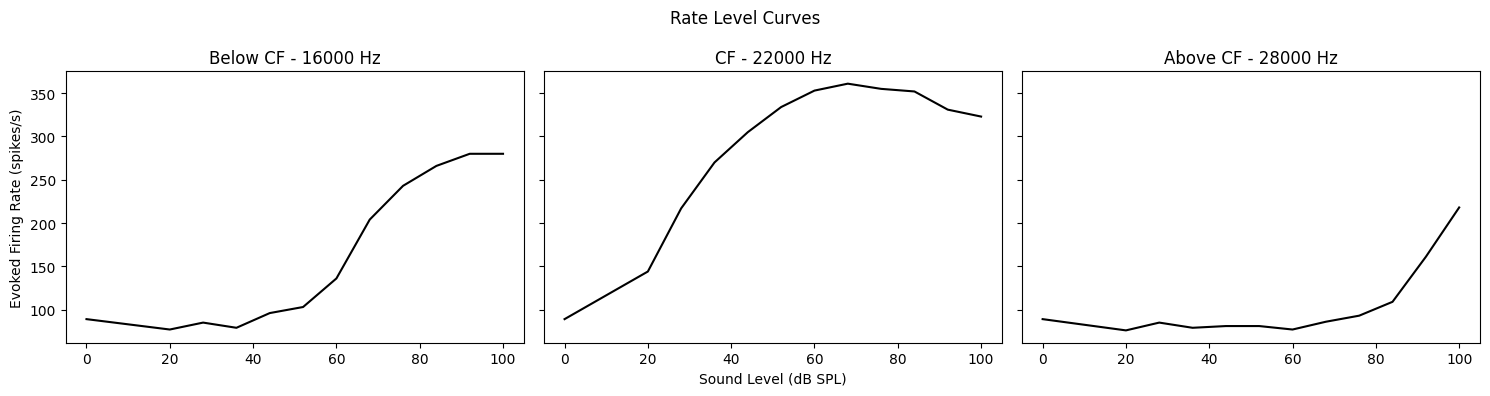

In [19]:
fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

axs[0].plot(levels_below_cf, list(rates_below_cf.values()), color='k')
axs[0].set_title(f'Below CF - {freq_below_cf} Hz')

axs[1].plot(levels_cf, list(rates_cf.values()), color='k')
axs[1].set_title(f'CF - {freq_cf} Hz')

axs[2].plot(levels_above_cf, list(rates_above_cf.values()), color='k')
axs[2].set_title(f'Above CF - {freq_above_cf} Hz')

axs[1].set_xlabel('Sound Level (dB SPL)')
axs[0].set_ylabel('Evoked Firing Rate (spikes/s)')

fig.suptitle('Rate Level Curves')

fig.tight_layout()

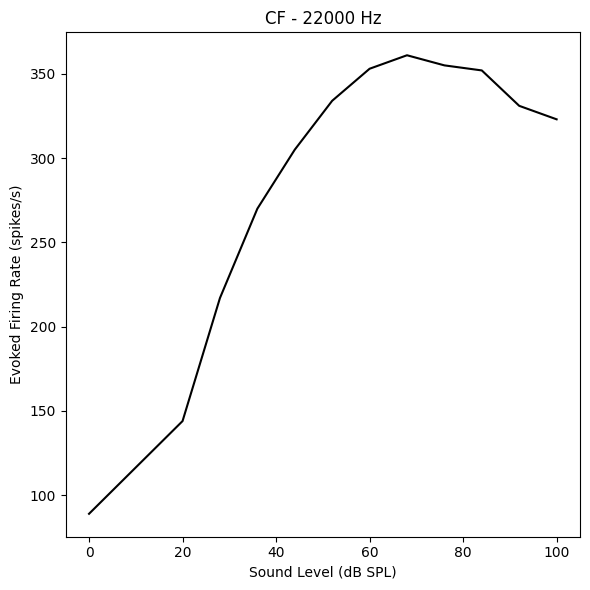

In [22]:
fig, axs = plt.subplots(1,1,figsize=(6,6), sharex=True, sharey=True)

axs.plot(levels_cf, list(rates_cf.values()), color='k')
axs.set_title(f'CF - {freq_cf} Hz')

axs.set_xlabel('Sound Level (dB SPL)')
axs.set_ylabel('Evoked Firing Rate (spikes/s)')

fig.tight_layout()
fig.savefig('RL_curve-normal_hearing.png', dpi=300)

#### Tuning DS->Pyr

In [7]:
sp_weight = t3_syn_weights['sp']
vp_weight = t3_syn_weights['vp']

In [8]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

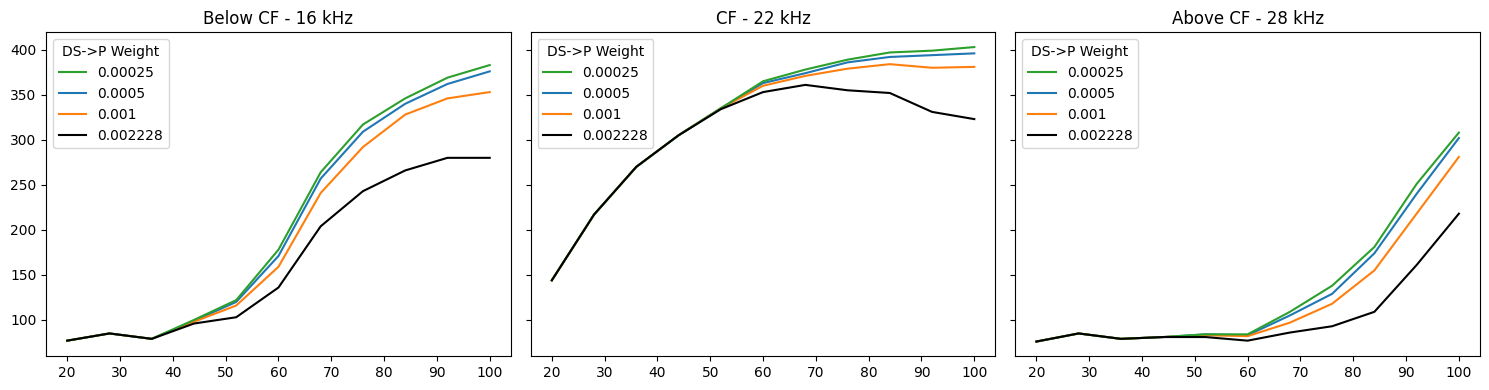

In [12]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'SPx{sp_weight}' in subdir_name) and (f'VPx{vp_weight}' in subdir_name):

                ds_weight = subdir_name.split('_')[2].split('DPx')[-1]

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_results_od = pickle.load(open(os.path.join(subdir.path, '1fs_11dbs_22000cf-results_od.pkl'), 'rb'))
                _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if float(ds_weight) == t3_syn_weights['dp']:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), color='k', label=ds_weight)
                else:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), label=ds_weight)

    handles, labels = axs[i].get_legend_handles_labels()
    order = np.argsort([float(label) for label in labels])
    axs[i].legend([handles[idx] for idx in order], [labels[idx] for idx in order],loc='upper left', title='DS->P Weight')
    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

fig.tight_layout()

#### Tuning Vert->Pyr

In [13]:
sp_weight = t3_syn_weights['sp']
dp_weight = t3_syn_weights['dp']

In [14]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

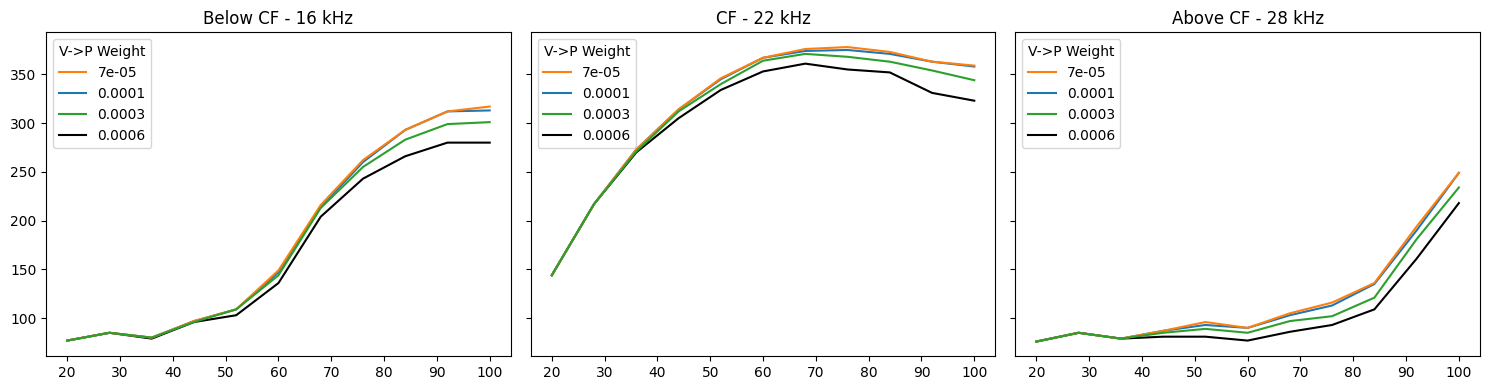

In [16]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'SPx{sp_weight}' in subdir_name) and (f'DPx{dp_weight}' in subdir_name):

                vert_weight = float(subdir_name.split('_')[1].split('VPx')[-1])

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_results_od = pickle.load(open(os.path.join(subdir.path, '1fs_11dbs_22000cf-results_od.pkl'), 'rb'))
                _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if vert_weight == t3_syn_weights['vp']:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), color='k', label=vert_weight)
                else:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), label=vert_weight)
    
    handles, labels = axs[i].get_legend_handles_labels()
    order = np.argsort([float(label) for label in labels])
    axs[i].legend([handles[idx] for idx in order], [labels[idx] for idx in order],loc='upper left', title='V->P Weight')
    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

# axs[-1].legend(loc='upper le', title='V->P Weight')

fig.tight_layout()

#### Tuning SGN->Pyr

In [17]:
vp_weight = t3_syn_weights['vp']
dp_weight = t3_syn_weights['dp']

In [18]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

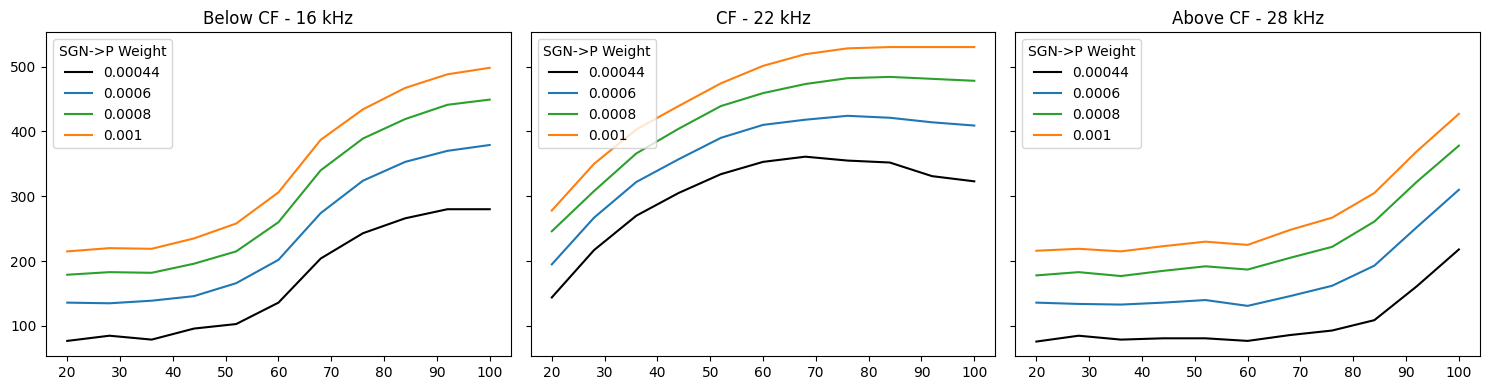

In [19]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(15,4), sharex=True, sharey=True)
axs = axs.ravel()

for i, freq_dir in enumerate([below_cf_dir, cf_dir, above_cf_dir]):

    for subdir in os.scandir(freq_dir):

        if subdir.is_dir():
            subdir_name = subdir.name
            if (f'VPx{vp_weight}' in subdir_name) and (f'DPx{dp_weight}' in subdir_name):

                sgc_weight = float(subdir_name.split('_')[0].split('SPx')[-1])

                subdir_data_norm = pickle.load(open(os.path.join(subdir.path, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
                subdir_results_od = pickle.load(open(os.path.join(subdir.path, '1fs_11dbs_22000cf-results_od.pkl'), 'rb'))
                _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                if sgc_weight == t3_syn_weights['sp']:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), color='k', label=sgc_weight)
                else:
                    axs[i].plot(subdir_levels, list(evoked_rates.values()), label=sgc_weight)
                # if sgc_weight == :

    axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

    handles, labels = axs[i].get_legend_handles_labels()
    order = np.argsort([float(label) for label in labels])
    axs[i].legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='upper left', title='SGN->P Weight')


# axs[-1].legend(loc='upper le', title='V->P Weight')

fig.tight_layout()

#### Combined

In [22]:
sgc_weights = [0.00044, 0.0006, 0.0008]  # 0.0002, 0.00026, 0.000327, 0.00038 (IV), 0.00044 (III), 0.0005
tv_weights = [0.0001, 0.0003, 0.0006]  # 0.0006 (III), 0.0012, 0.0018, 0.0024, 0.002705, 0.003, 0.0033, 0.0036, 0.0039 (IV)
ds_weights = [0.0005, 0.001, 0.002228]  # 0.002228 (default)

weight_combos = np.array(list(itertools.product(*[sgc_weights, tv_weights, ds_weights])))

In [23]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_11ls-10nreps-III'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_11ls-10nreps-III'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_11ls-10nreps-III'

In [24]:
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0, 1, len(weight_combos)))

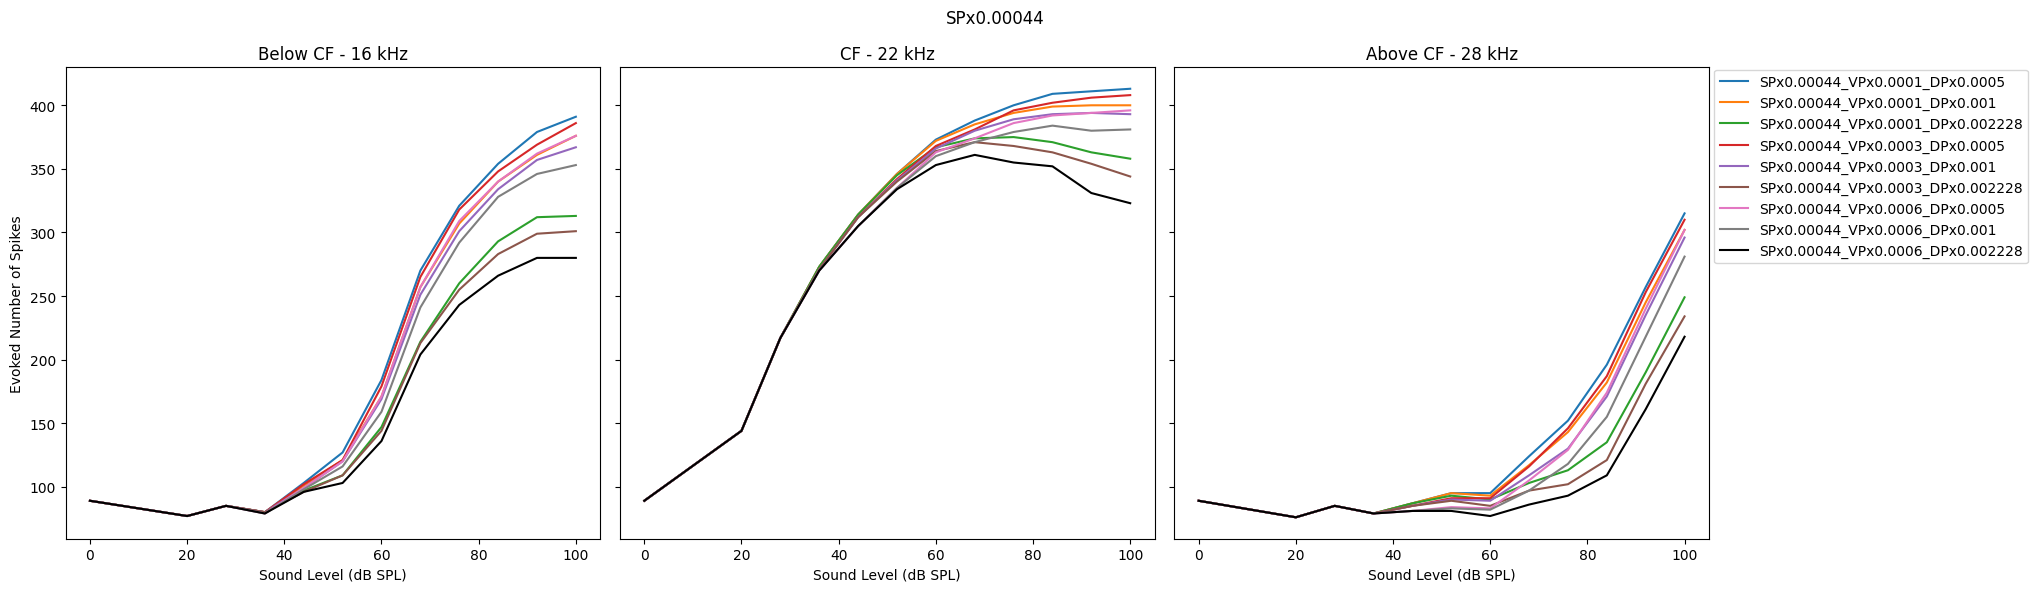

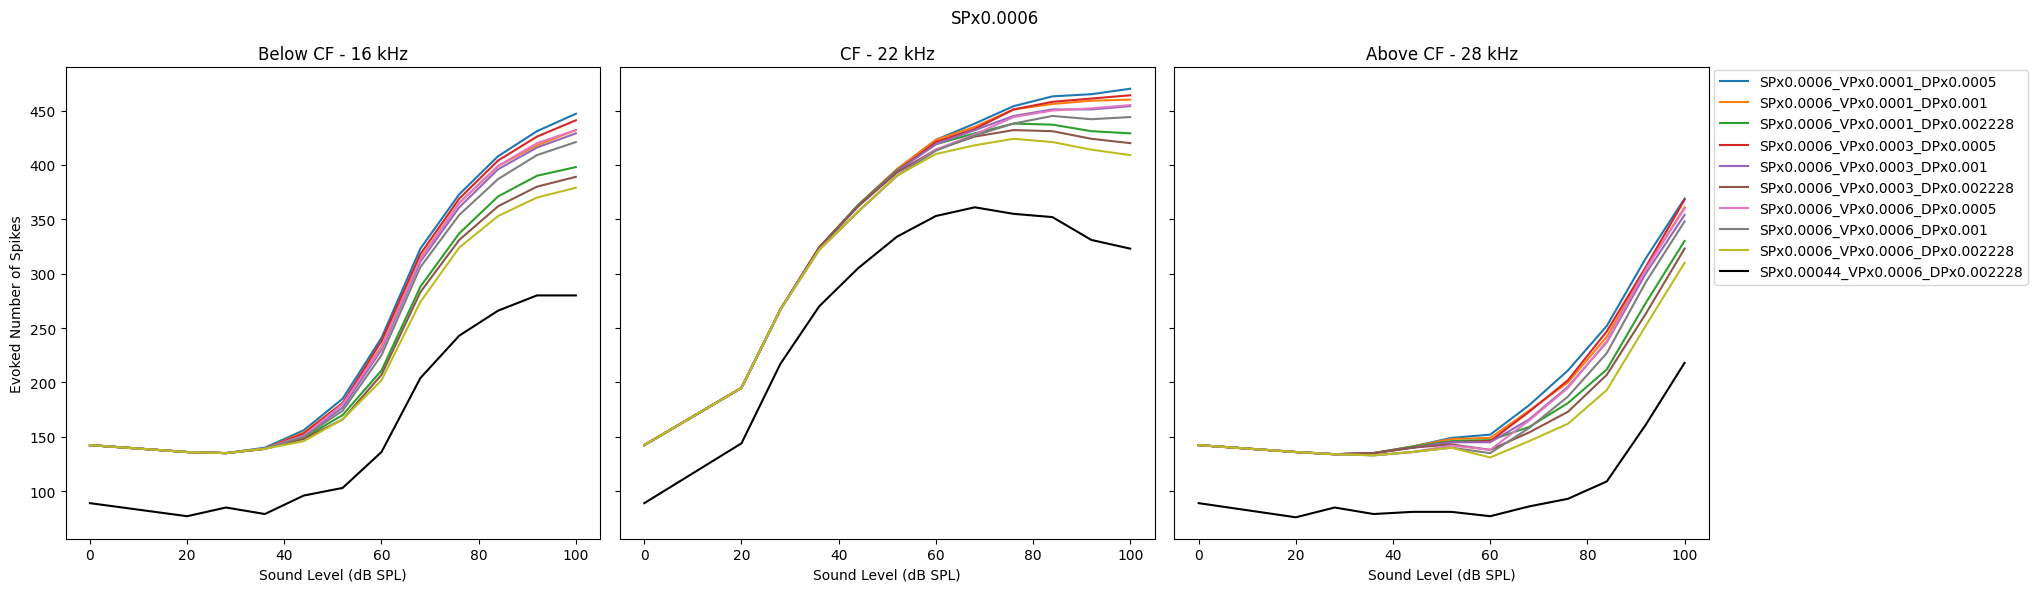

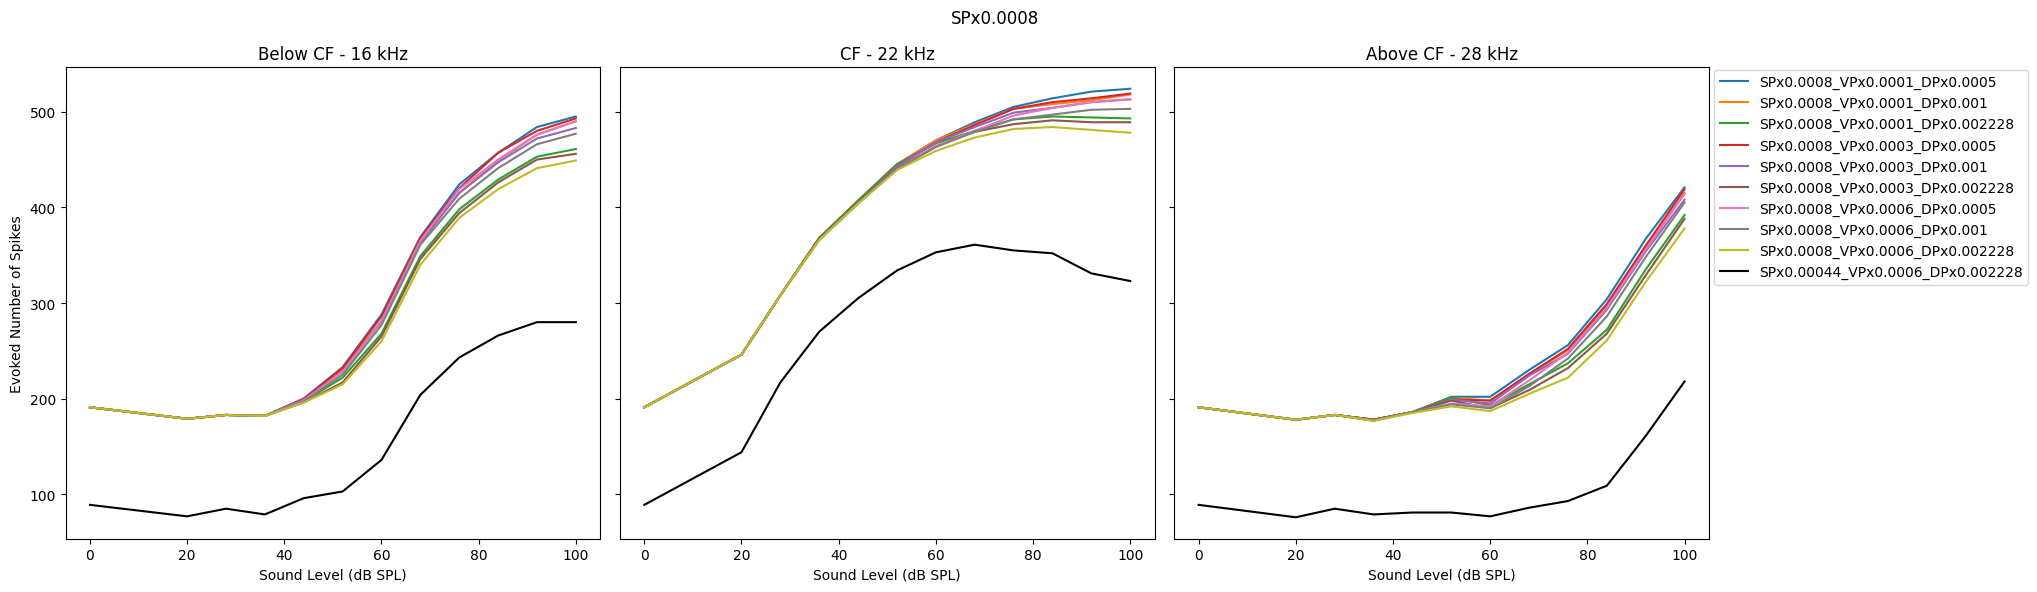

In [25]:
cf = ['Below CF', 'CF', 'Above CF']

default_levels = {}
default_rates = {}

for sgc_weight in sgc_weights:

    fig, axs = plt.subplots(1,3,figsize=(20,6), sharex=True, sharey=True)
    axs = axs.ravel()

    sgc_weight_combos = weight_combos[np.isin(weight_combos[:,0],sgc_weight)]

    for w_i, sgc_weight_combo in enumerate(sgc_weight_combos):

        sgc_w = sgc_weight_combo[0]
        tv_w = sgc_weight_combo[1]
        ds_w = sgc_weight_combo[2]

        below_cf_sim_dir = os.path.join(below_cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
        cf_sim_dir = os.path.join(cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
        above_cf_sim_dir = os.path.join(above_cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')

        for i, freq_dir in enumerate([below_cf_sim_dir, cf_sim_dir, above_cf_sim_dir]):

            subdir_results_od = pickle.load(open(os.path.join(freq_dir, '1fs_11dbs_22000cf-results_od.pkl'), 'rb'))
            _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
            spont_rate = get_spontaneous_firing_rates('pyramidal', subdir_results_od, stimpar['baseline'])

            subdir_data_norm = pickle.load(open(os.path.join(freq_dir, 'DATA-1fs_11dbs_22000cf-rate_level_curve.pkl'),'rb'))
            subdir_freq = subdir_data_norm['freqs'][0]
            subdir_levels = subdir_data_norm['levels']

            subdir_levels.insert(0,0)
            evoked_rates = {**{(subdir_freq, 0): spont_rate}, **evoked_rates}

            if (sgc_w == t3_syn_weights['sp']) and (tv_w == t3_syn_weights['vp']) and (ds_w == t3_syn_weights['dp']):
                default_levels[cf[i]] = subdir_levels
                default_rates[cf[i]] = list(evoked_rates.values())
                axs[i].plot(subdir_levels, list(evoked_rates.values()), label=f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}', color='k')
            else:
                axs[i].plot(subdir_levels, list(evoked_rates.values()), label=f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')

            axs[i].set_xlabel('Sound Level (dB SPL)')

            axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

        axs[0].set_ylabel('Evoked Number of Spikes')

    if sgc_weight != t3_syn_weights['sp']:
        axs[0].plot(default_levels[cf[0]], default_rates[cf[0]], label=f"SPx{t3_syn_weights['sp']}_VPx{t3_syn_weights['vp']}_DPx{t3_syn_weights['dp']}", color='k')
        axs[1].plot(default_levels[cf[1]], default_rates[cf[1]], label=f"SPx{t3_syn_weights['sp']}_VPx{t3_syn_weights['vp']}_DPx{t3_syn_weights['dp']}", color='k')
        axs[2].plot(default_levels[cf[2]], default_rates[cf[2]], label=f"SPx{t3_syn_weights['sp']}_VPx{t3_syn_weights['vp']}_DPx{t3_syn_weights['dp']}", color='k')

    axs[-1].legend(loc='upper right', bbox_to_anchor=[1.61,1.01])

    fig.suptitle(f'SPx{sgc_weight}')
    fig.tight_layout()

#### Homeostasis Factor

In [7]:
homeostasis_factors = [0.3, 0.2, 0.1, 1, 1.5, 2, 2.5, 3]

sgc_weight = 0.00044
tv_weight = 0.0006
ds_weight = 0.002228

weight_combos = [(np.round(sgc_weight*hf,7), np.round(tv_weight/hf,7), np.round(ds_weight/hf,7)) for hf in homeostasis_factors]

In [10]:
below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_14ls-10nreps-III-hf'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf'
above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_14ls-10nreps-III-hf'

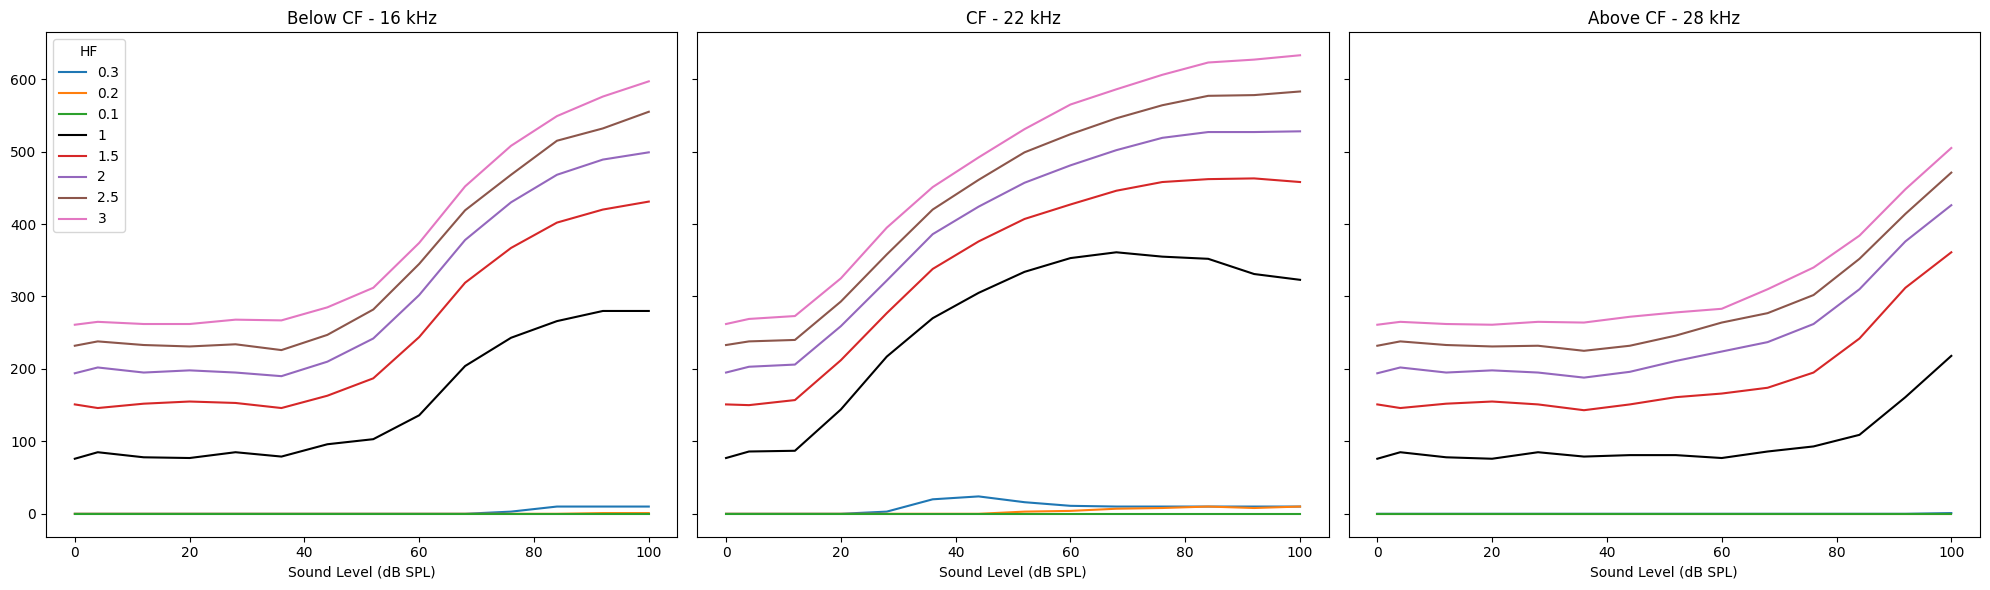

In [ ]:
cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,3,figsize=(20,6), sharex=True, sharey=True)
axs = axs.ravel()

for hf_i, hf in enumerate(homeostasis_factors):

    weight_combo = weight_combos[hf_i]
    sgc_w = weight_combo[0]
    tv_w = weight_combo[1]
    ds_w = weight_combo[2]

    below_cf_sim_dir = os.path.join(below_cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
    cf_sim_dir = os.path.join(cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
    above_cf_sim_dir = os.path.join(above_cf_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')

    for i, freq_dir in enumerate([below_cf_sim_dir, cf_sim_dir, above_cf_sim_dir]):

        subdir_results_od = pickle.load(open(os.path.join(freq_dir, '1fs_14dbs_22000cf-results_od.pkl'), 'rb'))
        _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])

        subdir_data_norm = pickle.load(open(os.path.join(freq_dir, 'DATA-1fs_14dbs_22000cf-rate_level_curve.pkl'),'rb'))
        subdir_freq = subdir_data_norm['freqs'][0]
        subdir_levels = subdir_data_norm['levels']

        # subdir_levels.insert(0,0)
        # evoked_rates = {**{(subdir_freq, 0): spont_rate}, **evoked_rates}

        if (sgc_w == t3_syn_weights['sp']) and (tv_w == t3_syn_weights['vp']) and (ds_w == t3_syn_weights['dp']):
            axs[i].plot(subdir_levels, list(evoked_rates.values()), label=hf, color='k')
        else:
            axs[i].plot(subdir_levels, list(evoked_rates.values()), label=hf)

        axs[i].set_xlabel('Sound Level (dB SPL)')
        axs[i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

axs[0].legend(loc='upper left', title='HF') #, bbox_to_anchor=[1.61,1.01])

# fig.suptitle(f'SPx{sgc_weight}')
fig.tight_layout()

#### Hair Cell Impairment

In [37]:
homeostasis_factors = [1]

sgc_weight = 0.00044
tv_weight = 0.0006
ds_weight = 0.002228

weight_combos = [(np.round(sgc_weight*hf,7), np.round(tv_weight/hf,7), np.round(ds_weight/hf,7)) for hf in homeostasis_factors]

In [24]:
# below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_14ls-10nreps-III-hf'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III_13000loss-hc-hf'
# above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_14ls-10nreps-III-hf'

In [38]:
cohcs = [0.5, 1]
cihcs = [0.5, 1]

chcs = np.array(list(itertools.product(*[cohcs, cihcs])))
chcs = {'Cohc': [[0.5, 1.0], [0.25, 1.0]],
        'Cihc': [[1.0, 0.5], [1.0, 0.25]]}

In [29]:
cf_sim_dir = os.path.join(cf_dir, 'COx1.0_CIx1.0', f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
subdir_results_od = pickle.load(open(os.path.join(cf_sim_dir, '1fs_14dbs_22000cf-results_od.pkl'), 'rb'))
_, cf_normal_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])

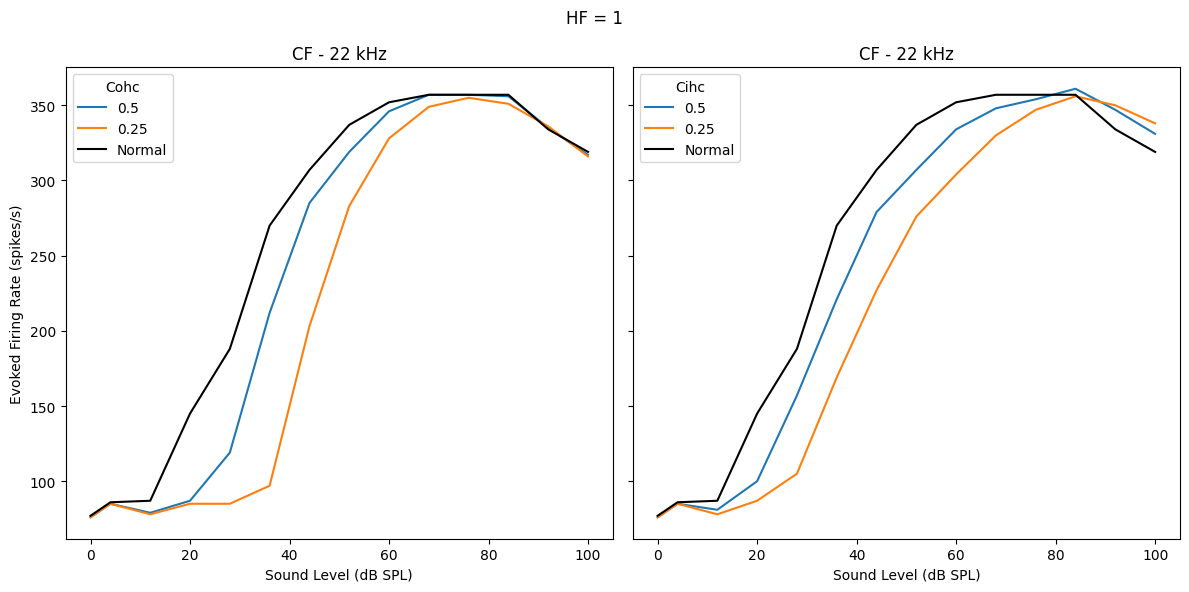

In [41]:
chcs = {'Cohc': [[0.5, 1.0], [0.25, 1.0]],
        'Cihc': [[1.0, 0.5], [1.0, 0.25]],
        'Cohc_Cihc': [[0.5, 0.5], [0.25, 0.25]]}

cf = ['Below CF', 'CF', 'Above CF']

fig, axs = plt.subplots(1,2,figsize=(12,6), sharex=True, sharey=True)
axs = axs.ravel()

for hc_i, chc in enumerate(['Cohc', 'Cihc']):

    for cohc, cihc in chcs[chc]:

        hear_dir = f'COx{cohc}_CIx{cihc}'

        for hf_i, hf in enumerate(homeostasis_factors):

            weight_combo = weight_combos[hf_i]
            sgc_w = weight_combo[0]
            tv_w = weight_combo[1]
            ds_w = weight_combo[2]

            # below_cf_sim_dir = os.path.join(below_cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
            cf_sim_dir = os.path.join(cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
            # above_cf_sim_dir = os.path.join(above_cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')

            for i, freq_dir in enumerate([cf_sim_dir]):
                i = 1

                subdir_results_od = pickle.load(open(os.path.join(freq_dir, '1fs_14dbs_22000cf-results_od.pkl'), 'rb'))
                _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
                spont_rate = get_spontaneous_firing_rates('pyramidal', subdir_results_od, stimpar['baseline'])

                subdir_data_norm = pickle.load(open(os.path.join(freq_dir, 'DATA-1fs_14dbs_22000cf-rate_level_curve-loss.pkl'),'rb'))
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                # subdir_levels.insert(0,0)
                # evoked_rates = {**{(subdir_freq, 0): spont_rate}, **evoked_rates}

                # if (cohc == 1.0) and (cihc == 1.0):
                #     axs[hc_i].plot(subdir_levels, list(evoked_rates.values()), label=f'Cohc={cohc}, Cihc={cihc}', color='k')
                # else:
                c_val = cohc if 'ohc' in chc else cihc
                c_val = f'Cohc={cohc}, Cihc={cihc}' if '_' in chc else c_val
                axs[hc_i].plot(subdir_levels, list(evoked_rates.values()), label=c_val)

                axs[hc_i].set_xlabel('Sound Level (dB SPL)')
                axs[hc_i].set_title(f'{cf[i]} - {subdir_freq//1000} kHz')

    axs[hc_i].plot(subdir_levels, list(cf_normal_rates.values()), label='Normal', color='k')
    axs[hc_i].legend(loc='upper left', title=chc) #, bbox_to_anchor=[1.61,1.01])

axs[0].set_ylabel('Evoked Firing Rate (spikes/s)')

fig.suptitle(f'HF = 1')
fig.tight_layout()
fig.savefig('RL_curve-hc_impairment.png', dpi=300)

##### Homeostasis Factor

In [7]:
# below_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-16000Hz_14ls-10nreps-III-hf'
cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III_13000loss-hc-hf'
# above_cf_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-28000Hz_14ls-10nreps-III-hf'

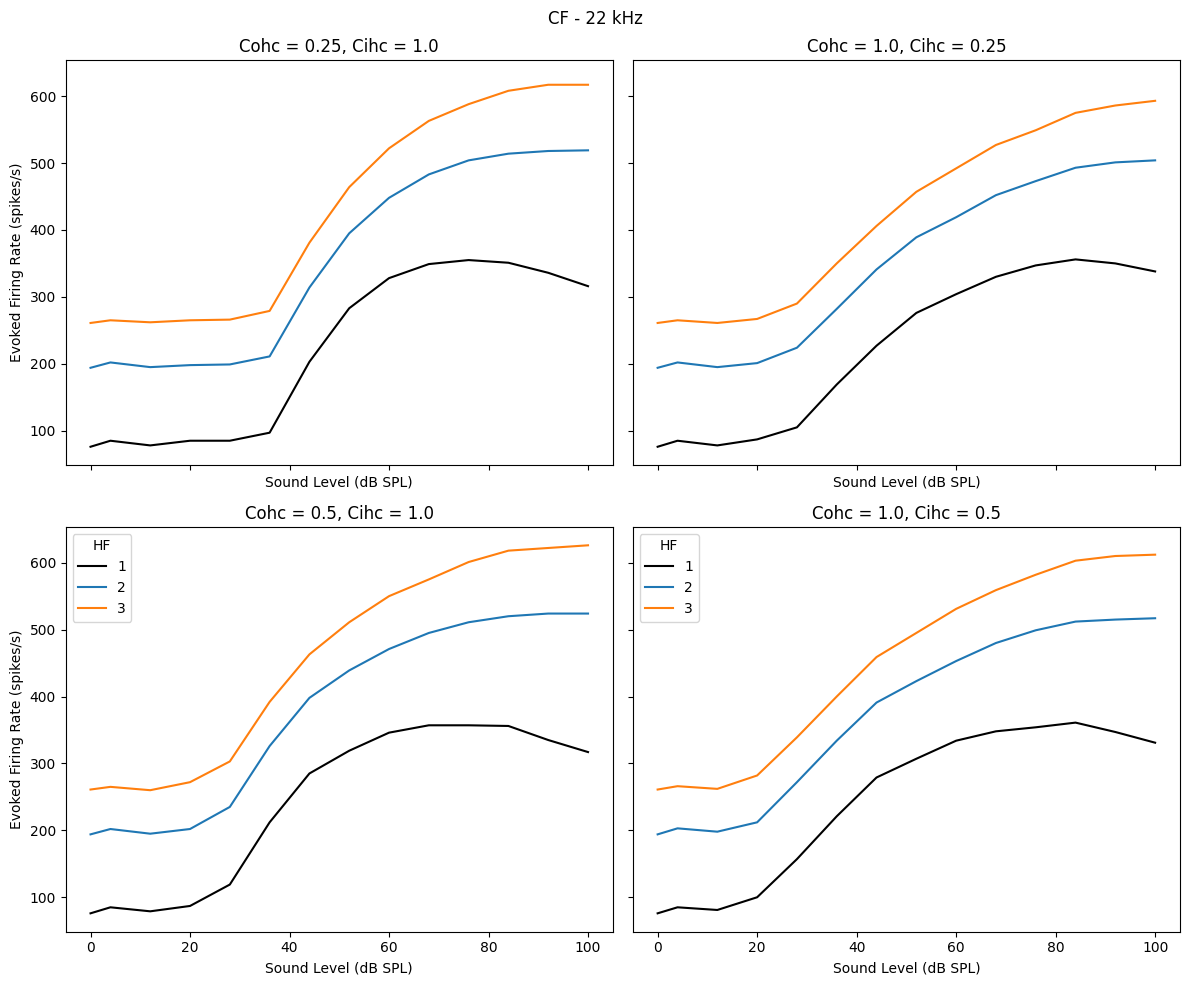

In [15]:
homeostasis_factors = [1, 2, 3]

sgc_weight = 0.00044
tv_weight = 0.0006
ds_weight = 0.002228

weight_combos = [(np.round(sgc_weight*hf,7), np.round(tv_weight/hf,7), np.round(ds_weight/hf,7)) for hf in homeostasis_factors]

chcs = {'Cohc': [[0.25, 1.0], [0.5, 1.0]],
        'Cihc': [[1.0, 0.25], [1.0, 0.5]]}

cf = ['Below CF', 'CF', 'Above CF']


fig, axs = plt.subplots(2,2,figsize=(12,10), sharex=True, sharey=True)
# axs = axs.ravel()

for hc_i, chc in enumerate(['Cohc', 'Cihc']):

    for c_i, (cohc, cihc) in enumerate(chcs[chc]):

        hear_dir = f'COx{cohc}_CIx{cihc}'

        for hf_i, hf in enumerate(homeostasis_factors):

            weight_combo = weight_combos[hf_i]
            sgc_w = weight_combo[0]
            tv_w = weight_combo[1]
            ds_w = weight_combo[2]

            # below_cf_sim_dir = os.path.join(below_cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
            cf_sim_dir = os.path.join(cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')
            # above_cf_sim_dir = os.path.join(above_cf_dir, hear_dir, f'SPx{sgc_w}_VPx{tv_w}_DPx{ds_w}')

            for i, freq_dir in enumerate([cf_sim_dir]):
                i = 1

                subdir_results_od = pickle.load(open(os.path.join(freq_dir, '1fs_14dbs_22000cf-results_od.pkl'), 'rb'))
                _, evoked_rates = get_evoked_firing_rates('pyramidal', subdir_results_od, stimpar['response'])
                spont_rate = get_spontaneous_firing_rates('pyramidal', subdir_results_od, stimpar['baseline'])

                subdir_data_norm = pickle.load(open(os.path.join(freq_dir, 'DATA-1fs_14dbs_22000cf-rate_level_curve-loss.pkl'),'rb'))
                subdir_freq = subdir_data_norm['freqs'][0]
                subdir_levels = subdir_data_norm['levels']

                # subdir_levels.insert(0,0)
                # evoked_rates = {**{(subdir_freq, 0): spont_rate}, **evoked_rates}

                if (sgc_w == t3_syn_weights['sp']) and (tv_w == t3_syn_weights['vp']) and (ds_w == t3_syn_weights['dp']):
                    axs[c_i, hc_i].plot(subdir_levels, list(evoked_rates.values()), label=hf, color='k')
                else:
                    axs[c_i, hc_i].plot(subdir_levels, list(evoked_rates.values()), label=hf)

                axs[c_i, hc_i].set_xlabel('Sound Level (dB SPL)')
                axs[c_i, hc_i].set_title(f'Cohc = {cohc}, Cihc = {cihc}' )

    axs[c_i, hc_i].legend(loc='upper left', title='HF') #, bbox_to_anchor=[1.61,1.01])

axs[0,0].set_ylabel('Evoked Firing Rate (spikes/s)') 
axs[1,0].set_ylabel('Evoked Firing Rate (spikes/s)') 

fig.suptitle(f'{cf[i]} - {subdir_freq//1000} kHz')
fig.tight_layout()
# fig.savefig('RL_curve-hc_impairment-homeo_factor.png', dpi=300)

### Probability Density

In [73]:
results_od_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228/1fs_14dbs_22000cf-results_od.pkl', 'rb'))
_, rates_cf = get_evoked_firing_rates('pyramidal', results_od_cf, stimpar['response'])
spont_rate_cf = get_spontaneous_firing_rates('pyramidal', results_od_cf, stimpar['baseline'])
data_norm_cf = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_14dbs_22000cf-rate_level_curve.pkl', 'rb'))
freq_cf = data_norm_cf['freqs'][0]
levels_cf = data_norm_cf['levels']

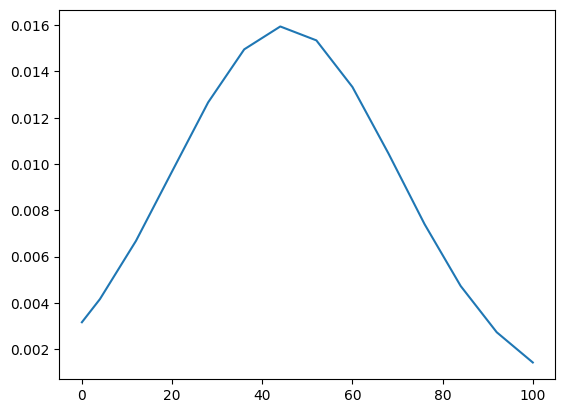

In [76]:
prob_dense = norm.pdf(levels_cf, 45, 25)
plt.plot(levels_cf, prob_dense)

In [83]:
rl_cf = np.array(list(rates_cf.values())).flatten()

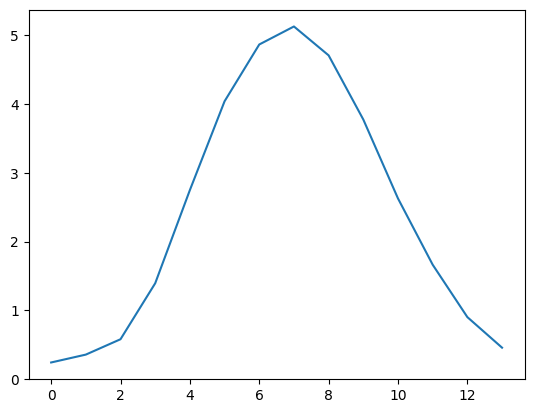

In [87]:
plt.plot(np.multiply(rl_cf, prob_dense))

### Evoked Firing Rates

In [18]:
combo_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228'
results_df = pickle.load(open(os.path.join(combo_dir,'1fs_14dbs_22000cf-results_od.pkl'), 'rb'))

In [56]:
# pyr_ids, pyr_rates = get_evoked_firing_rates('pyramidal', results_df, stimpar['response'])
ds_ids, ds_rates = get_evoked_firing_rates('dstellate', results_df, stimpar['response'])
vert_ids, vert_rates = get_evoked_firing_rates('tuberculoventral', results_df, stimpar['response'])
sgc_ids, sgc_rates = get_evoked_firing_rates('sgc', results_df, stimpar['response'])

In [ ]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')


In [28]:
colors = {'pyramidal': 'tab:blue',
          'vertical': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

In [59]:
freq = 22000
level = 60

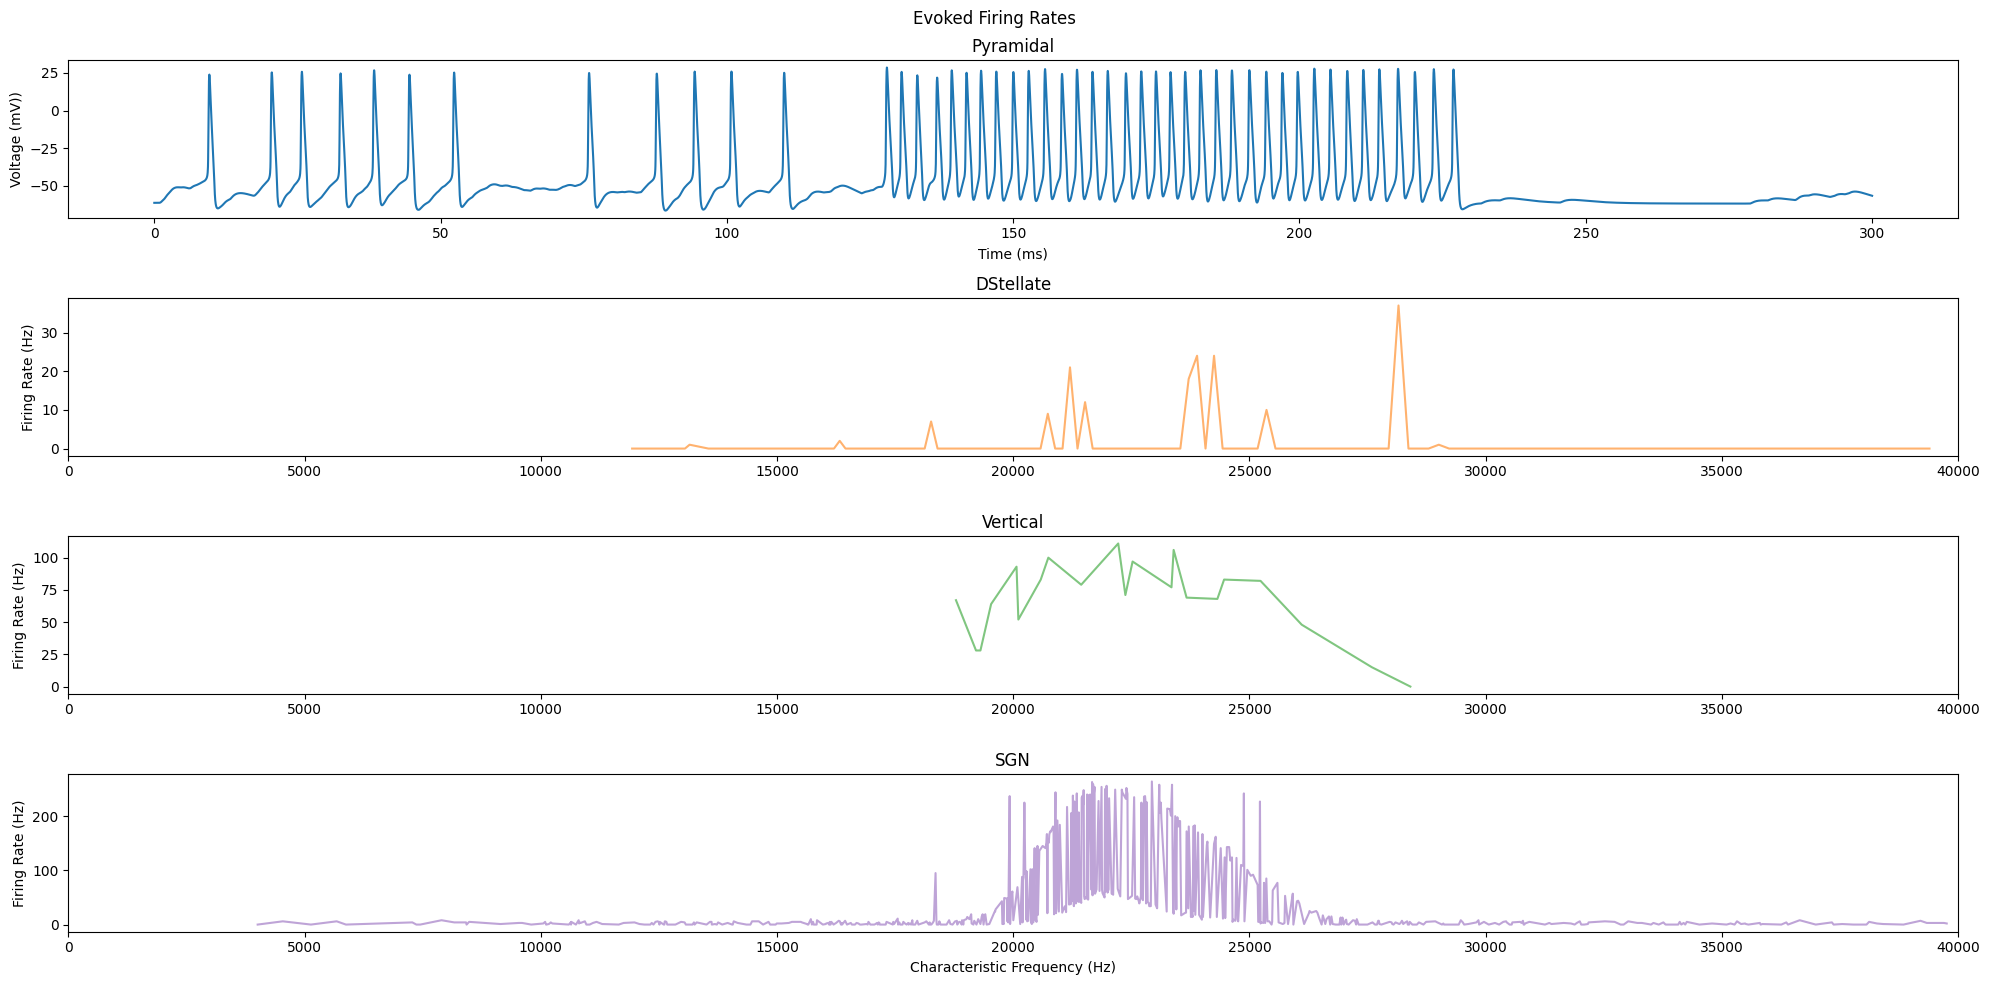

In [67]:
fig, axs = plt.subplots(4,1, figsize=(20,10))
axs = axs.ravel()

t = results_df[f'f0: {freq}  dBspl: {level}'][1][0]['t']
pyr_trace = results_df[f'f0: {freq}  dBspl: {level}'][1][0][('pyramidal', 2340)][0]
axs[0].plot(t, pyr_trace, color=colors['pyramidal'])
axs[0].set_title('Pyramidal')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('Voltage (mV))')
# axs[0].plot(freqs, ( pyr_rates[(freq, level)]), zorder=13, alpha=0.6, label=cihc)
# axs[0].set_title('Pyramidal')
# axs[0].legend(loc='upper right', bbox_to_anchor=(1.06, 1.05), title='Cihc')

axs[1].plot(ds_cfs[ds_ids[(freq, level)]], ds_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['dstellate'])
axs[1].set_title('DStellate')
axs[1].set_xlim([0,40000])
axs[1].set_ylabel('Firing Rate (Hz)')
# axs[1].legend(loc='upper right')

axs[2].plot(vert_cfs[vert_ids[(freq, level)]], vert_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['vertical'])
axs[2].set_title('Vertical')
axs[2].set_xlim([0,40000])
axs[2].set_ylabel('Firing Rate (Hz)')
# axs[2].legend(loc='upper right')

axs[3].plot(sgc_cfs[sgc_ids[(freq, level)]], sgc_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['sgc'])
axs[3].set_title('SGN')
axs[3].set_xlim([0,40000])
axs[3].set_ylabel('Firing Rate (Hz)')
# axs[3].legend(loc='upper right')

axs[-1].set_xlabel('Characteristic Frequency (Hz)')

fig.suptitle('Evoked Firing Rates')
fig.tight_layout()



### Spontaneous Firing Rates

In [ ]:
combo_dir = '/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228'
results_df = pickle.load(open(os.path.join(combo_dir,'1fs_14dbs_22000cf-results_od.pkl'), 'rb'))

In [68]:
ds_ids, ds_spont_rates = get_spontaneous_firing_rates('dstellate', results_df, stimpar['baseline'])
vert_ids, vert_spont_rates = get_spontaneous_firing_rates('tuberculoventral', results_df, stimpar['baseline'])
sgc_ids, sgc_spont_rates = get_spontaneous_firing_rates('sgc', results_df, stimpar['baseline'])

In [69]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')

colors = {'pyramidal': 'tab:blue',
          'vertical': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

freq = 22000
level = 60

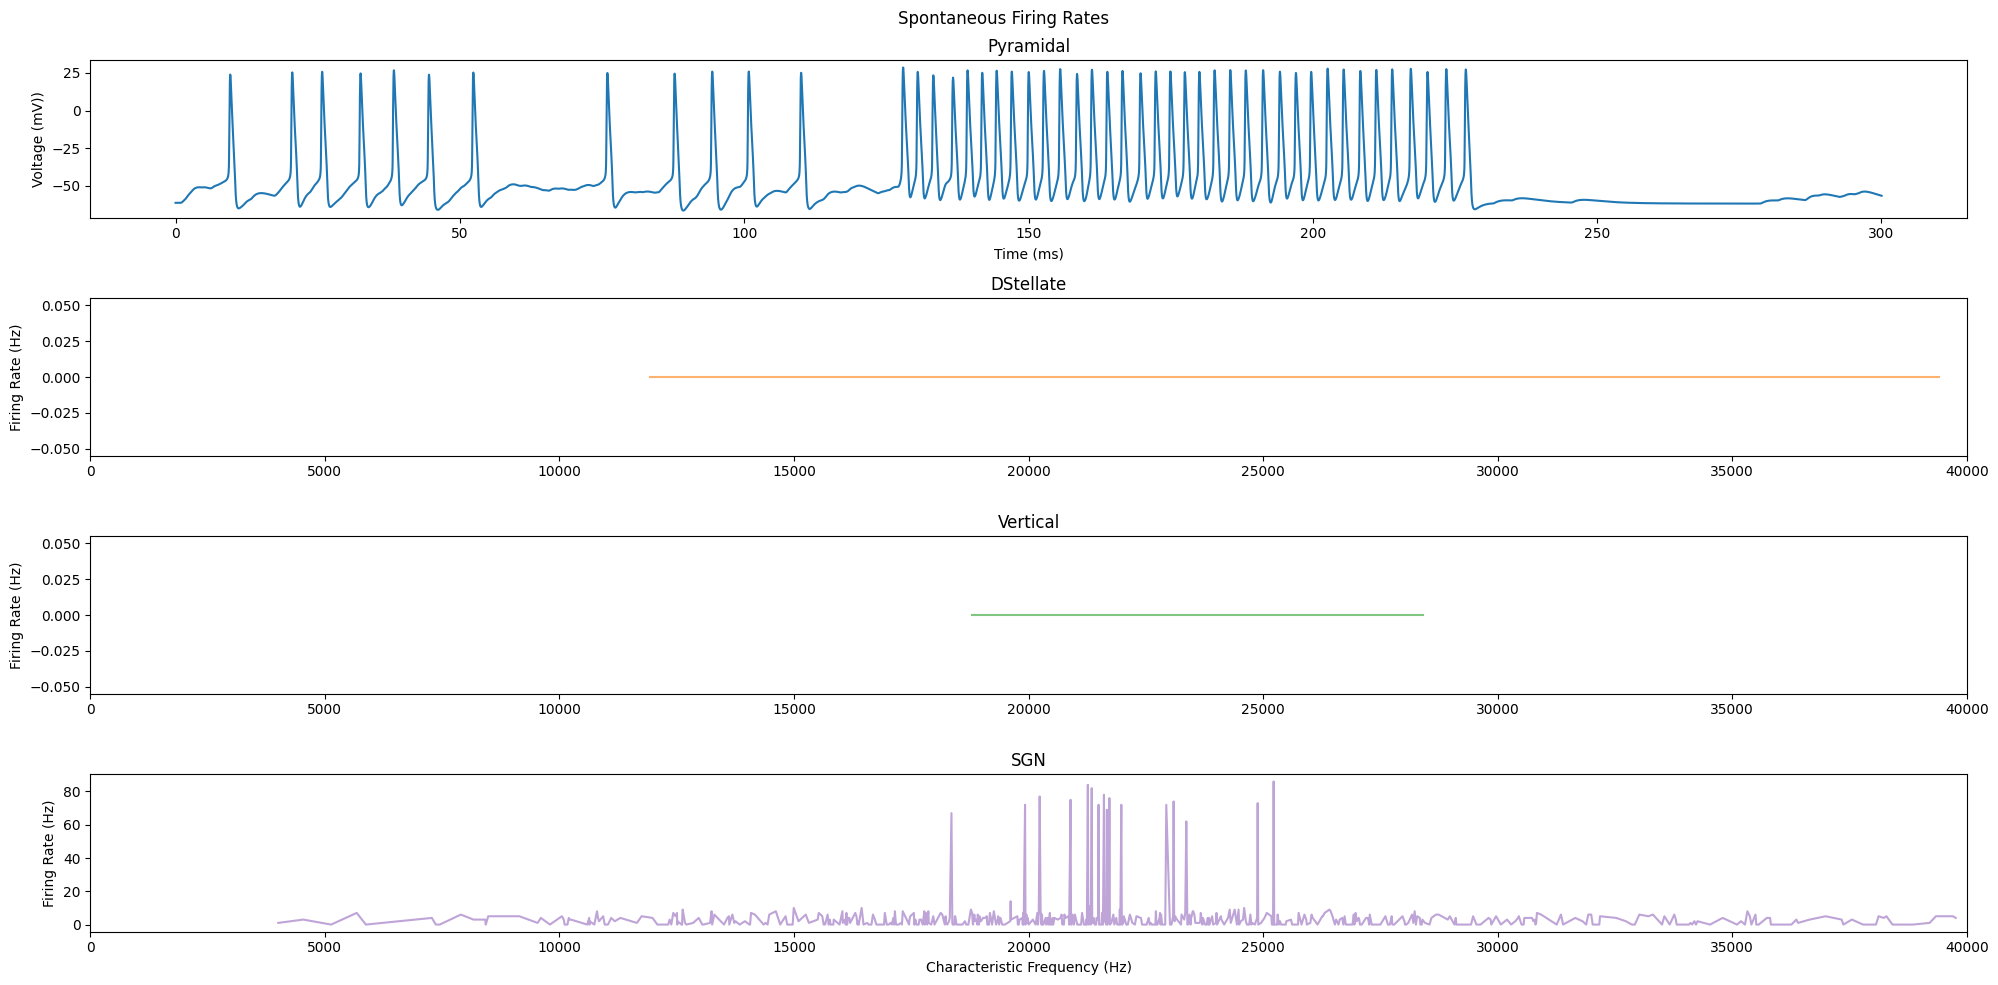

In [70]:
fig, axs = plt.subplots(4,1, figsize=(20,10))
axs = axs.ravel()

t = results_df[f'f0: {freq}  dBspl: {level}'][1][0]['t']
pyr_trace = results_df[f'f0: {freq}  dBspl: {level}'][1][0][('pyramidal', 2340)][0]
axs[0].plot(t, pyr_trace, color=colors['pyramidal'])
axs[0].set_title('Pyramidal')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('Voltage (mV))')
# axs[0].plot(freqs, ( pyr_rates[(freq, level)]), zorder=13, alpha=0.6, label=cihc)
# axs[0].set_title('Pyramidal')
# axs[0].legend(loc='upper right', bbox_to_anchor=(1.06, 1.05), title='Cihc')

axs[1].plot(ds_cfs[ds_ids[(freq, level)]], ds_spont_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['dstellate'])
axs[1].set_title('DStellate')
axs[1].set_xlim([0,40000])
axs[1].set_ylabel('Firing Rate (Hz)')
# axs[1].legend(loc='upper right')

axs[2].plot(vert_cfs[vert_ids[(freq, level)]], vert_spont_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['vertical'])
axs[2].set_title('Vertical')
axs[2].set_xlim([0,40000])
axs[2].set_ylabel('Firing Rate (Hz)')
# axs[2].legend(loc='upper right')

axs[3].plot(sgc_cfs[sgc_ids[(freq, level)]], sgc_spont_rates[(freq, level)], zorder=13, alpha=0.6, color=colors['sgc'])
axs[3].set_title('SGN')
axs[3].set_xlim([0,40000])
axs[3].set_ylabel('Firing Rate (Hz)')
# axs[3].legend(loc='upper right')

axs[-1].set_xlabel('Characteristic Frequency (Hz)')

fig.suptitle('Spontaneous Firing Rates')
fig.tight_layout()



### PSTH

In [8]:
stimpar = {
        "dur": 0.3,
        "pip": 0.1,
        "start": [0.125],       # equals response start in seconds
        "baseline": [25, 125],  # baseline duration has to equal response duration
        "response": [125, 225],
    }

In [9]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')

pop_cfs = {'pyramidal': pyr_cfs,
           'sgc': sgc_cfs,
           'tuberculoventral': vert_cfs,
           'dstellate': ds_cfs}

pyr_id = pyr_pop.select(1, cf=22e3,create=True)
pyr_cell = pyr_pop.get_cell(pyr_id)

sgc_pop.connect(pyr_pop, ds_pop, vert_pop)
ds_pop.connect(pyr_pop, vert_pop)
vert_pop.connect(pyr_pop)
pyr_pop.resolve_inputs(depth=1)

sgc_in_ids = list(pyr_pop._pre_connections[0]._cell_indexes.values())

pre: sgc, post: pyramidal
pyramidal 2340: 48 sgc
pre: dstellate, post: pyramidal
pyramidal 2340: 15 dstellate
pre: tuberculoventral, post: pyramidal
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
getcellpars: modelType:  TVmouse
pyramidal 2340: 21 tuberculoventral


In [10]:
resp_type = 'III'
sgc_pyr = 0.00044 if 'III' in resp_type else 0.00038  # type III - 0.00044, type IV - 0.00038, default - 0.000327
vert_pyr = 0.0006 if 'III' in resp_type else 0.0039  # type III - 0.0006, type IV - 0.0039, default - 0.0027
results_od = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228/1fs_14dbs_22000cf-results_od.pkl', 'rb'))
subdir_data_norm = pickle.load(open('/data/scrook/dcnmodel_scratch/output/rate_level-22kHZ_single_cell-simple_syns-22000Hz_14ls-10nreps-III-hf/SPx0.00044_VPx0.0006_DPx0.002228/DATA-1fs_14dbs_22000cf-rate_level_curve.pkl','rb'))
subdir_levels = subdir_data_norm['levels']

In [11]:
subdir_levels

[np.float64(0.0),
 np.float64(4.0),
 np.float64(12.0),
 np.float64(20.0),
 np.float64(28.0),
 np.float64(36.0),
 np.float64(44.0),
 np.float64(52.0),
 np.float64(60.0),
 np.float64(68.0),
 np.float64(76.0),
 np.float64(84.0),
 np.float64(92.0),
 np.float64(100.0)]

In [15]:
freq =  22000
level = 92

In [16]:
cell_types = ['pyramidal','tuberculoventral', 'dstellate', 'sgc']

colors = {'pyramidal': 'tab:blue',
          'tuberculoventral': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

cell_ids = {cell_type: [] for cell_type in cell_types}
cell_spikes = {cell_type: [] for cell_type in cell_types}

single_cell_ids = {'dstellate': 502,
                   'tuberucloventral': 3831,
                   'sgc': 7810}

cell_count = 0
trials = results_od[f'f0: {freq}  dBspl: {level}'][1]

for trial, cells in trials.items():
    for vec in cells.items():
        temp = 7
        if isinstance(vec[0], str):
            t = vec[1]
            continue

        cell_type = vec[0][0]
        cell_id = vec[0][1]
        spikes = vec[1][1]

        if 'pyr' in cell_type:
            pyr_trace = vec[1][0]

        if cell_type in single_cell_ids.keys():
            if cell_id == single_cell_ids[cell_type]:
                cell_ids[cell_type].append(cell_id)
                cell_spikes[cell_type].append(spikes)
        else:
            cell_ids[cell_type].append(cell_id)
            cell_spikes[cell_type].append(spikes)

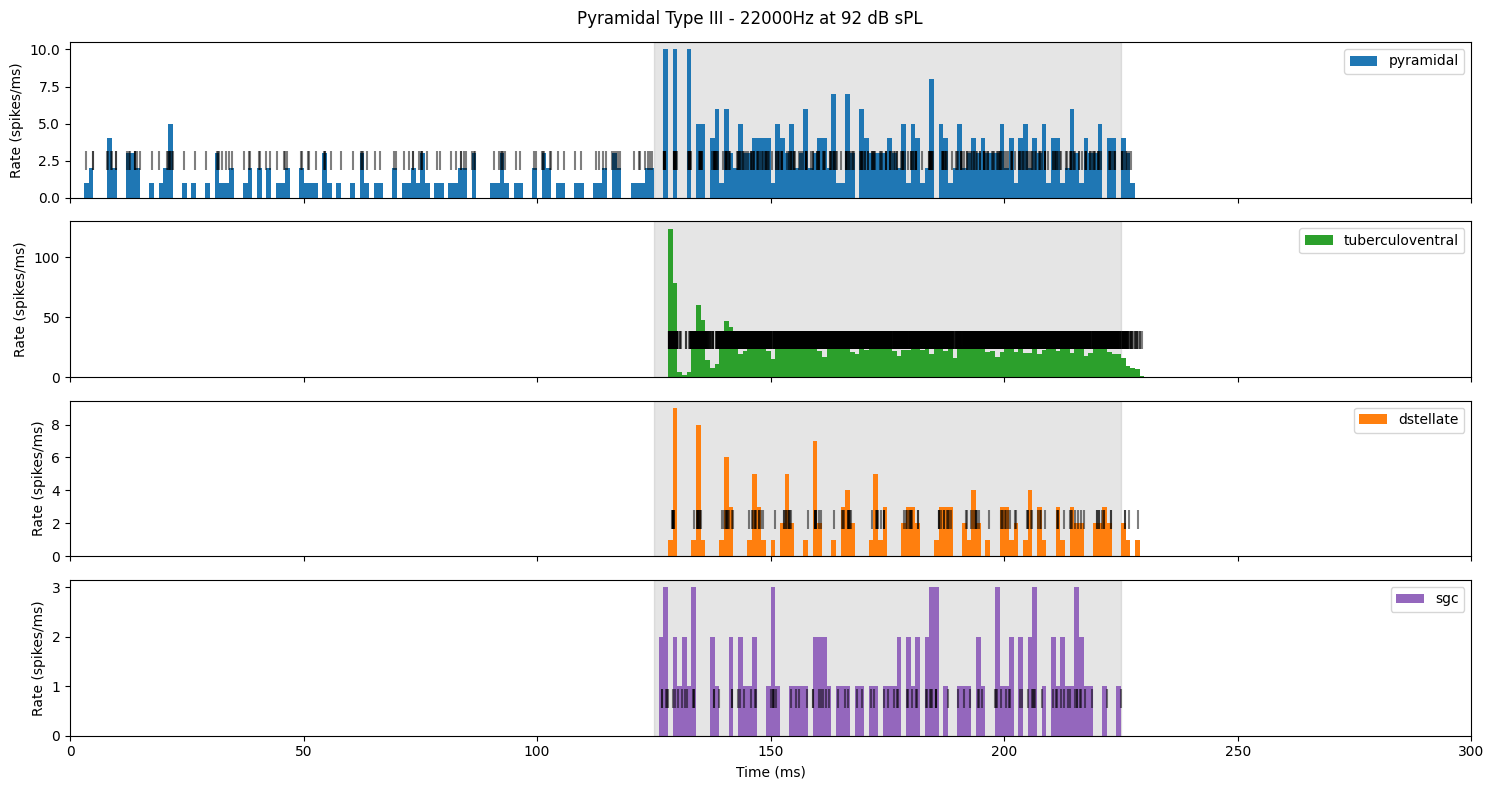

In [17]:
fig, axs = plt.subplots(len(cell_types), 1, figsize=(15,8), sharex=True, sharey=False)
axs = axs.ravel() 

for i, cell_type in enumerate(cell_types):

    cell_spike_times = np.concatenate(cell_spikes[cell_type])

    bin_size = 0.001  # 1 ms
    bins = np.arange(0, stimpar['dur']+bin_size, bin_size)

    counts, edges = np.histogram(cell_spike_times / 1000, bins=bins)

    psth = counts * (bin_size * 1000)  # spikes / s
    bin_centers = edges[:-1] + bin_size / 2

    axs[i].axvspan(stimpar['response'][0]/1000, stimpar['response'][1]/1000, color='grey', alpha=0.2)

    axs[i].bar(bin_centers, psth, width=bin_size, color=colors[cell_type], label=cell_type)

    axs[i].eventplot(cell_spike_times/1000, lineoffsets=psth.max()/4, linelengths=psth.max()/8, color='k', alpha=0.5)

    axs[i].set_ylabel('Rate (spikes/ms)')

    locs = axs[i].get_xticks()
    axs[i].set_xticks(locs)
    axs[i].set_xticklabels([int(loc*1000) for loc in locs])
    axs[i].set_xlim([0,(stimpar['dur'])])

    axs[i].legend(loc='upper right')

    # axs[i].set_title(cell_type)

axs[-1].set_xlabel('Time (ms)')

fig.suptitle(f'Pyramidal Type {resp_type} - {freq }Hz at {level} dB sPL')
fig.tight_layout()
# fig.savefig(f'SPC_PSTH-{freq}Hz_{level}dB-{resp_type}.png', dpi=300)